In [19]:
import pandas as pd
import numpy as np

import math

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import src.data.dataprep as prep

In [20]:
nl_data_list = []

for i in range(27):
    # Import the base data and resample it from 5 minutes to hourly
    try:
        nl_data = prep.dutch_data('../../data/Dutchdata_clean/building_' + str(i) + '.parquet', 'h')
    except:
        continue
    nl_data_list.append(nl_data)

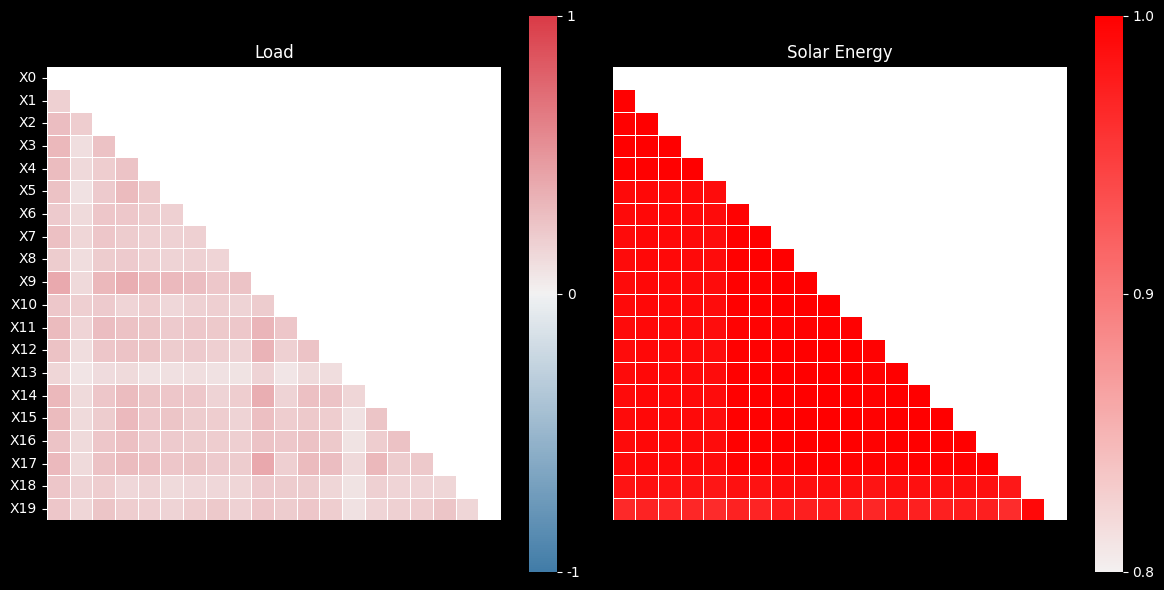

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create dataframes
load_df = pd.DataFrame({f'X{i}': df['load'].reset_index(drop=True) for i, df in enumerate(nl_data_list)})
solar_df = pd.DataFrame({f'X{i}': df['solar_energy'].reset_index(drop=True) for i, df in enumerate(nl_data_list)})

# Correlation matrices
load_corr = load_df.corr()
solar_corr = solar_df.corr()

# Mask the UPPER triangle (keep lower triangle visible)
mask_upper = np.triu(np.ones_like(load_corr, dtype=bool))

# Set up plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6), facecolor='black')

# --- LOAD HEATMAP ---
cbar1 = sns.heatmap(load_corr, mask=mask_upper, ax=axes[0],
                    cmap=sns.diverging_palette(240, 10, as_cmap=True),
                    vmin=-1, vmax=1, square=True,
                    cbar=True, cbar_kws={"ticks": [-1, 0, 1]},
                    linewidths=0.5, xticklabels=False, yticklabels=True)

axes[0].set_title("Load", color='white')
axes[0].tick_params(colors='white')
cbar1.collections[0].colorbar.ax.set_yticklabels(["-1", "0", "1"])
cbar1.collections[0].colorbar.ax.tick_params(colors='white')

# --- SOLAR ENERGY HEATMAP ---
cbar2 = sns.heatmap(solar_corr, mask=mask_upper, ax=axes[1],
                    cmap=sns.light_palette("red", as_cmap=True),
                    vmin=0.8, vmax=1.0, square=True,
                    cbar=True, cbar_kws={"ticks": [0.8, 0.9, 1.0]},
                    linewidths=0.5, xticklabels=False, yticklabels=False)

axes[1].set_title("Solar Energy", color='white')
axes[1].tick_params(colors='white')
cbar2.collections[0].colorbar.ax.set_yticklabels(["0.8", "0.9", "1.0"])
cbar2.collections[0].colorbar.ax.tick_params(colors='white')

plt.tight_layout()
plt.show()


In [ ]:
solar_energy = []
max_load = []
jolien_pv = []
jolien_load = []
pv_to_consumption = []

for i in range(len(nl_data_list)):
    solar_energy.append(nl_data_list[i]['solar_energy'].max())
    max_load.append(math.floor(nl_data_list[i]['load'].resample('D').sum().max()))
    jolien_load.append(math.floor(nl_data_list[i]['load'].resample('YE').sum().max() * 1.17 / 1000))
    pv_to_consumption.append(6 / (nl_data_list[i]['load'].resample('YE').sum().max() / 1000))
                       
solar_energy = np.array(solar_energy)
max_load = np.array(max_load)
jolien_pv = np.array(jolien_pv)
jolien_load = np.array(jolien_load)
pv_to_consumption = np.array(pv_to_consumption)

In [ ]:
nl_data_list[0]['load'].resample('YE').sum().max() / 1000

In [ ]:
# Compute ratio (handling division by zero)
max_ratio = np.round(max_load / solar_energy, 2)
jolien_pv_ratio = np.round(jolien_pv / solar_energy, 2)
jolien_ratio = np.round(jolien_load / solar_energy, 2)

# X locations for the clusters
x = np.arange(len(solar_energy)) * 1.5  
width = 0.3  

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(24, 12))

# Plot bar charts
bars1 = ax1.bar(x - width, solar_energy, width, color='b', label='Solar Energy')
bars2 = ax1.bar(x, max_load, width, color='g', label='Max Load')
bars3 = ax1.bar(x+width, jolien_pv, width, color='r', label='Jolien PV Load')
bars4 = ax1.bar(x+2*width, jolien_load, width, color='y', label='Jolien Load')

# Labels and title
ax1.set_xlabel("House")
ax1.set_ylabel("Energy (kWh)")
plt.title("Average and Maximum daily Load vs. Solar Energy per household")

# Set x-ticks to align with clusters
ax1.set_xticks(x)
ax1.set_xticklabels([f"House {i}" for i in range(len(solar_energy))], fontsize=7)

# Legend
ax1.legend(loc="upper left")

# Color scale (Red → Green) for avg ratio
norm = plt.Normalize(vmin=np.min(max_ratio), vmax=np.max(max_ratio))
cmap = plt.get_cmap("RdYlGn_r")  # Reverse RdYlGn
colors = [mcolors.to_hex(cmap(norm(value))) for value in max_ratio]

# Create a table with row names + ratios
table_data = [
    ["Building"] + [f"House {i}" for i in range(len(max_ratio))] + ["Building"],
    ["Jolien PV Ratio"] + list(jolien_pv_ratio.astype(str)) + ["Avg Ratio"],
    ["Max Ratio"] + list(max_ratio.astype(str)) + ["Max Ratio"]
]

# Create the table
table = ax1.table(cellText=table_data,
                  cellLoc='center',
                  loc='bottom',
                  bbox=[0, -0.3, 1, 0.2])  # Adjust position & size

# Apply colors to the avg ratio values (skipping the first column)
for i in range(1, len(max_ratio) + 1):  
    table._cells[(1, i)].set_facecolor(colors[i - 1])

# Adjust layout to fit the table
plt.subplots_adjust(bottom=0.4)

# Show plot
plt.show()